# Generated Power 可视化与求和

这个 notebook 读取 `temp.csv`，绘制 `generated_power` 折线图，并直接对 `generated_power` 求和。

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

csv_path = Path("temp.csv")
if not csv_path.exists():
    csv_path = Path("scripts") / "temp.csv"

df = pd.read_csv(csv_path)
df.head()

,sample,generated_power
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [3]:
required_columns = {"sample", "generated_power"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"CSV 缺少列: {sorted(missing_columns)}")

df = df.sort_values("sample").reset_index(drop=True)
df[["sample", "generated_power"]].describe()

,sample,generated_power
count,64.000000,64.00000
mean,31.500000,2056.40625
std,18.618987,2370.06720
min,0.000000,0.00000
25%,15.750000,0.00000
50%,31.500000,694.00000
75%,47.250000,4346.50000
max,63.000000,5949.00000


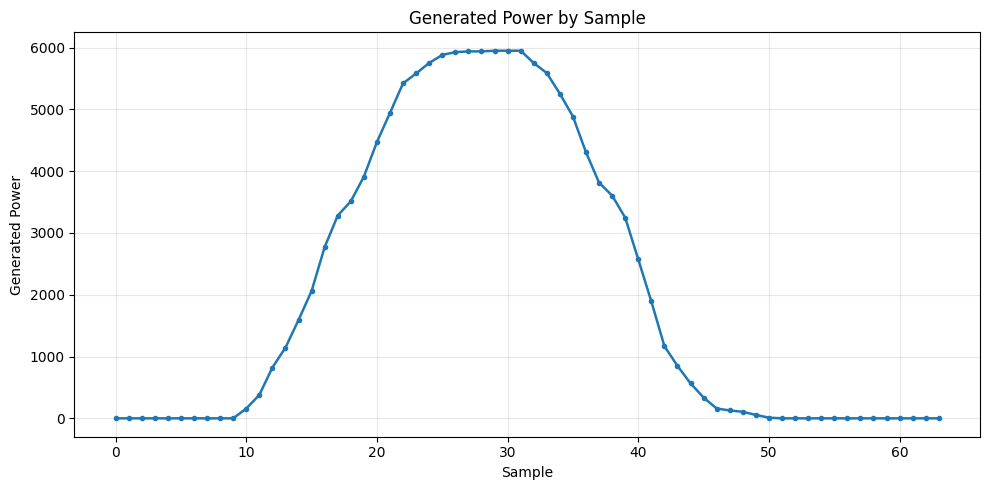

In [4]:
sample = df["sample"].to_numpy(dtype=float)
power = df["generated_power"].to_numpy(dtype=float)

plt.figure(figsize=(10, 5))
plt.plot(sample, power, marker="o", linewidth=1.8, markersize=3)
plt.xlabel("Sample")
plt.ylabel("Generated Power")
plt.title("Generated Power by Sample")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
total_generated_power = power.sum()

print(f"Sum of generated_power: {total_generated_power:.6f}")

Sum of generated_power: 131610.000000
